preprocess frames and extract edges 
-triplets are inside dataset folder . we have to synplify them . converts these frame sto edge maps so that ai can focus more on movement

what the code does 
-load the triplets from the dataset folder 
-uses CANNY EDGE DETECTION  to turn them into white lines on black background
- this will also show the result 

libraries are imported
input is taken from folder dataset - folder triplet 
output is in folder dataset - folder edges 

In [4]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
INPUT_DIR = 'dataset/triplets'   # Where your triplets are
OUTPUT_DIR = 'dataset/edges'     # Where to save the edge maps

# Canny Parameters (Adjust these if edges are too faint or too messy)
LOWER_THRESHOLD = 100
UPPER_THRESHOLD = 200

egde - a place in am image where something changes sharply (object boundary , face outline , buliding outline , text borders)
if pixel colours changes suddently then it is an egde 
binary edge map - has only 2 values 
0 - black
255 - white
here the edges are white and everything else is black (just that nothing else)
white pixels means edge , black pixel means - not and edge

why do this ?
colur image has three channels - reg , green and blue 
converts colur into grey scale . image goes from rich colour black background with white line 
edges capture structure . this helps to detect motion boundaries preserve object shapes , avoid blurry interpolaton

In [5]:
def extract_edges(image):
    """
    Converts a color image to a binary edge map.
    """
    # 1. Convert to Grayscale (Canny needs grayscale)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # 2. Apply Canny Edge Detection
    # Edges below 'Lower' are discarded. 
    # Edges above 'Upper' are kept. 
    # Values in between are kept only if connected to a strong edge.
    edges = cv2.Canny(gray, LOWER_THRESHOLD, UPPER_THRESHOLD)
    
    return edges

the above function is called . gets all the image triplets .
loops through the image , reads each image 
saves them to output directory 
finally a random image from these is shown 

🔍 Searching for images in 'dataset/triplets'...
✅ Found 408 images to process...


  0%|          | 0/408 [00:00<?, ?it/s]

Processing Complete. Showing a sample:


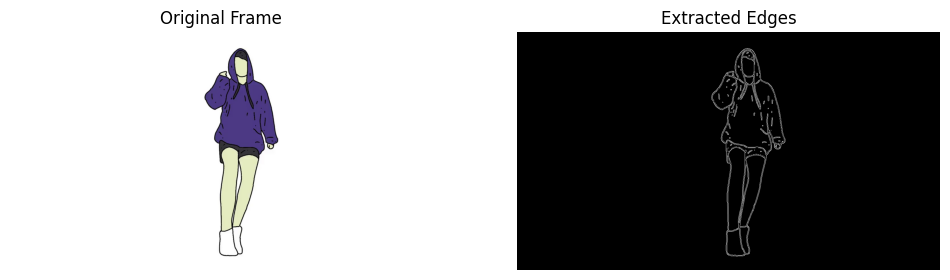

In [6]:
# --- MAIN EXECUTION ---
# Ensure the root output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- CORRECTION START: Replaced os.listdir with os.walk ---
# OLD CODE: all_images = [f for f in os.listdir(INPUT_DIR) if f.endswith('.png')]
# WHY IT FAILED: It ignored subfolders where your images are actually stored.

print(f"🔍 Searching for images in '{INPUT_DIR}'...")
all_image_paths = []

# os.walk recursively searches every subfolder inside INPUT_DIR
for root, dirs, files in os.walk(INPUT_DIR):
    for file in files:
        # Check for both .png and .jpg just in case
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            # We store the FULL path (e.g., "dataset/triplets/video1/001.png")
            full_path = os.path.join(root, file)
            all_image_paths.append(full_path)

all_image_paths.sort() # Ensure we process them in order
# --- CORRECTION END ---

# Safety check: Prevent crash if list is still empty
if len(all_image_paths) == 0:
    print("❌ ERROR: No images found. Check if 'dataset/triplets' has subfolders with images.")
else:
    print(f"✅ Found {len(all_image_paths)} images to process...")

    # We loop through them and process
    for img_path in tqdm(all_image_paths):
        
        # 1. Read Image (img_path is now the full path)
        frame = cv2.imread(img_path)
        
        if frame is None:
            continue

        # 2. Extract Edges (Using the function from your previous cell)
        edge_map = extract_edges(frame)
        
        # 3. Save to Output Directory
        # --- PATH CORRECTION ---
        # We need to mirror the subfolder structure so we don't lose organization.
        # Get relative path (e.g. "video1/001.png") instead of just "001.png"
        rel_path = os.path.relpath(img_path, INPUT_DIR) 
        save_path = os.path.join(OUTPUT_DIR, rel_path)
        
        # Create the specific subfolder for this video in the output directory
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        
        cv2.imwrite(save_path, edge_map)

    # --- VISUALIZATION CHECK ---
    print("Processing Complete. Showing a sample:")

    # Pick the first image found
    sample_path = all_image_paths[0]
    
    # Reconstruct the output path for this specific sample
    rel_sample_path = os.path.relpath(sample_path, INPUT_DIR)
    sample_edge_path = os.path.join(OUTPUT_DIR, rel_sample_path)

    original = cv2.imread(sample_path)
    edge_result = cv2.imread(sample_edge_path)

    if original is not None and edge_result is not None:
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        
        # Convert BGR to RGB for correct color display
        ax[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        ax[0].set_title("Original Frame")
        ax[0].axis('off')

        ax[1].imshow(edge_result, cmap='gray')
        ax[1].set_title("Extracted Edges")
        ax[1].axis('off')

        plt.show()
    else:
        print("Could not display sample (image read failed).")